In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df_raw = pd.read_csv('../../Anexos/Data_Caso_Propuesto.csv')
print(f'Dimensiones iniciales: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas')
print('\n')
print(df_raw.info())

Dimensiones iniciales: 463 filas, 12 columnas


<class 'pandas.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Codigo                  463 non-null    int64  
 1   Ciudad                  463 non-null    str    
 2   Departamento            463 non-null    str    
 3   Barrio                  40 non-null     str    
 4   Direccion               463 non-null    str    
 5   Area Terreno            463 non-null    float64
 6   Area Construida         463 non-null    float64
 7   Detalle Disponibilidad  463 non-null    str    
 8   Estrato                 463 non-null    str    
 9   Precio                  463 non-null    float64
 10  Tipo de Inmueble        463 non-null    str    
 11  Datos Adicionales       118 non-null    str    
dtypes: float64(3), int64(1), str(8)
memory usage: 43.5 KB
None


In [5]:
df_raw.isnull().sum()

Codigo                      0
Ciudad                      0
Departamento                0
Barrio                    423
Direccion                   0
Area Terreno                0
Area Construida             0
Detalle Disponibilidad      0
Estrato                     0
Precio                      0
Tipo de Inmueble            0
Datos Adicionales         345
dtype: int64

In [6]:
barrio_null = df_raw[df_raw['Barrio'].isnull()].shape[0]
porcentaje_barrio_null = barrio_null / df_raw.shape[0] * 100
datos_adicionales_null = df_raw[df_raw['Datos Adicionales'].isnull()].shape[0]
porcentaje_datos_adicionales_null = datos_adicionales_null / df_raw.shape[0] * 100
print(f'Porcentaje de valores nulos en la columna "Barrio": {porcentaje_barrio_null:.2f}% ({barrio_null} registros)')
print(f'Porcentaje de valores nulos en la columna "Datos Adicionales": {porcentaje_datos_adicionales_null:.2f}% ({datos_adicionales_null} registros)')

Porcentaje de valores nulos en la columna "Barrio": 91.36% (423 registros)
Porcentaje de valores nulos en la columna "Datos Adicionales": 74.51% (345 registros)


In [7]:
df_raw.head()

,Codigo,Ciudad,Departamento,Barrio,Direccion,Area Terreno,Area Construida,Detalle Disponibilidad,Estrato,Precio,Tipo de Inmueble,Datos Adicionales
0,17180,BOGOTA,CUNDINAMARCA,NaN,AV CR 7 NO. 166 - 51 LT B,0.00,0.0,COMERCIALIZABLE CON RESTRICCION,TRES,2.958081e+10,LOTE COMERCIAL,ESTE INMUEBLE SE COMERCIALIZARÁ A TRAVES DE SU...
1,19292,BOGOTA,CUNDINAMARCA,NaN,CL 72 No. 12 - 77,0.00,0.0,COMERCIALIZABLE,COMERCIAL,1.646059e+10,EDIFICIO,NaN
2,19292,BOGOTA,CUNDINAMARCA,NaN,CL 72 No. 12 - 77,0.00,0.0,COMERCIALIZABLE VENTA ANTICIPADA,COMERCIAL,1.646059e+10,EDIFICIO,NaN
3,2575,SOGAMOSO,BOYACÁ,CENTRO,CRA. 10 #11- 78/80 Ó CL 12 # 9 - 77/85 Ó CALLE...,1655.08,7269.0,COMERCIALIZABLE CON RESTRICCION,CUATRO,1.376828e+10,CLINICA,ESTE INMUEBLE SE COMERCIALIZARÁ A TRAVÉS DE SU...
4,11409,BUGA,VALLE DEL CAUCA,VEREDA CHAMBIMBAL,LT A1-A24 B1-B79 C1-C51 D1-D9 STA ROSA LT1-46 ...,3217197.00,22724.0,COMERCIALIZABLE FIDUCIA,RURAL,4.523379e+10,LOTE MIXTO,NaN


In [8]:
df_raw[df_raw.duplicated(subset=['Codigo'], keep=False)]
print(f'Número de códigos repetidos: {df_raw[df_raw.duplicated(subset=['Codigo'], keep=False)].shape[0]}')
print(f'''Valores de los códigos repetidos: 
{df_raw[df_raw.duplicated(subset=['Codigo'], keep=False) == True][['Codigo', 'Detalle Disponibilidad']]}''')

Número de códigos repetidos: 14
Valores de los códigos repetidos: 
    Codigo            Detalle Disponibilidad
1    19292                   COMERCIALIZABLE
2    19292  COMERCIALIZABLE VENTA ANTICIPADA
61   19210                   COMERCIALIZABLE
62   19210  COMERCIALIZABLE VENTA ANTICIPADA
64   19209                   COMERCIALIZABLE
65   19209  COMERCIALIZABLE VENTA ANTICIPADA
66   19211                   COMERCIALIZABLE
67   19211  COMERCIALIZABLE VENTA ANTICIPADA
70   19212                   COMERCIALIZABLE
71   19212  COMERCIALIZABLE VENTA ANTICIPADA
72   19213                   COMERCIALIZABLE
73   19213  COMERCIALIZABLE VENTA ANTICIPADA
82   19214                   COMERCIALIZABLE
83   19214  COMERCIALIZABLE VENTA ANTICIPADA


In [9]:
conteo_estrato = df_raw['Estrato'].value_counts(normalize=True)
porcentaje_estratos = conteo_estrato * 100
print(f'Porcentaje de valores en cada estrato:')
for estrato, porcentaje in porcentaje_estratos.items():
    print(f'  Estrato {estrato}: {porcentaje:.2f}%')

Porcentaje de valores en cada estrato:
  Estrato COMERCIAL: 66.31%
  Estrato RURAL: 8.64%
  Estrato UNO: 4.54%
  Estrato TRES: 4.10%
  Estrato CUATRO: 4.10%
  Estrato INDUSTRIAL: 3.46%
  Estrato DOS: 3.46%
  Estrato SEIS: 3.24%
  Estrato CINCO: 2.16%


In [10]:
estrato_comercial = df_raw['Estrato']=='COMERCIAL'
estrato_rural = df_raw['Estrato']=='RURAL'
estrato_industrial = df_raw['Estrato']=='INDUSTRIAL'
total_estrato_numericos = df_raw[~df_raw['Estrato'].isin(['COMERCIAL', 'RURAL', 'INDUSTRIAL'])].shape[0]
sumatoria_estratos = estrato_comercial + estrato_industrial + estrato_rural
print(f'''Número de propiedades en el estrato: 
      Comercial: {estrato_comercial.sum()} 
      Rural: {estrato_rural.sum()} 
      Industrial: {estrato_industrial.sum()} 
      Total: {sumatoria_estratos.sum()}, ({sumatoria_estratos.sum()/df_raw.shape[0]*100:.2f}%)''')
print(f'Propiedades en estratos numéricos: {total_estrato_numericos} ({total_estrato_numericos/df_raw.shape[0]*100:.2f}%)')

Número de propiedades en el estrato: 
      Comercial: 307 
      Rural: 40 
      Industrial: 16 
      Total: 363, (78.40%)
Propiedades en estratos numéricos: 100 (21.60%)


In [11]:
area_terreno_cuenta_0 = df_raw[df_raw['Area Terreno'] == 0].shape[0]
area_construida_cuenta_0 = df_raw[df_raw['Area Construida'] == 0].shape[0]
area_terreno_igual_0 = area_terreno_cuenta_0 / df_raw.shape[0] * 100
area_construida_igual_0 = area_construida_cuenta_0 / df_raw.shape[0] * 100

print(f'Porcentaje de viviendas con área de terreno igual a 0: {area_terreno_igual_0:.2f}% ({area_terreno_cuenta_0})')
print(f'Porcentaje de viviendas con área de construcción igual a 0: {area_construida_igual_0:.2f}% ({area_construida_cuenta_0})')

Porcentaje de viviendas con área de terreno igual a 0: 96.11% (445)
Porcentaje de viviendas con área de construcción igual a 0: 97.84% (453)


In [12]:
df = df_raw.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Codigo                  463 non-null    int64  
 1   Ciudad                  463 non-null    str    
 2   Departamento            463 non-null    str    
 3   Barrio                  40 non-null     str    
 4   Direccion               463 non-null    str    
 5   Area Terreno            463 non-null    float64
 6   Area Construida         463 non-null    float64
 7   Detalle Disponibilidad  463 non-null    str    
 8   Estrato                 463 non-null    str    
 9   Precio                  463 non-null    float64
 10  Tipo de Inmueble        463 non-null    str    
 11  Datos Adicionales       118 non-null    str    
dtypes: float64(3), int64(1), str(8)
memory usage: 43.5 KB


In [13]:
# Eliminar codigos duplicados conservando unicamente un registro por codigo especificar detalle disponibilidad 'COMERCIALIZABLE'

# 1. Identificar los codigos duplicados del dataset
codigos_duplicados = df[df.duplicated(subset=['Codigo'], keep=False)]['Codigo'].unique()

# 2. Definir la condicion exacta de las filas a Eliminar
condicion_eliminar = ((df['Codigo'].isin(codigos_duplicados)) & (df['Detalle Disponibilidad'] == 'COMERCIALIZABLE VENTA ANTICIPADA'))

# 3. Conservar las filas que no cumplen esa condicion
df = df[~condicion_eliminar]

df.info()

<class 'pandas.DataFrame'>
Index: 456 entries, 0 to 462
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Codigo                  456 non-null    int64  
 1   Ciudad                  456 non-null    str    
 2   Departamento            456 non-null    str    
 3   Barrio                  40 non-null     str    
 4   Direccion               456 non-null    str    
 5   Area Terreno            456 non-null    float64
 6   Area Construida         456 non-null    float64
 7   Detalle Disponibilidad  456 non-null    str    
 8   Estrato                 456 non-null    str    
 9   Precio                  456 non-null    float64
 10  Tipo de Inmueble        456 non-null    str    
 11  Datos Adicionales       112 non-null    str    
dtypes: float64(3), int64(1), str(8)
memory usage: 46.3 KB


In [14]:
# Descartar columnas con mas de l70% de ausencia de informacion (Barrio, Datos Adicionales)
df.drop(columns=['Barrio', 'Datos Adicionales', 'Area Terreno', 'Area Construida'], inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 456 entries, 0 to 462
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Codigo                  456 non-null    int64  
 1   Ciudad                  456 non-null    str    
 2   Departamento            456 non-null    str    
 3   Direccion               456 non-null    str    
 4   Detalle Disponibilidad  456 non-null    str    
 5   Estrato                 456 non-null    str    
 6   Precio                  456 non-null    float64
 7   Tipo de Inmueble        456 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 32.1 KB


In [26]:
df['Precio_M'] = df['Precio'] / 1_000_000
print(df[['Precio', 'Precio_M']].head(3))

         Precio    Precio_M
0  2.958081e+10  29580.8119
1  1.646059e+10  16460.5915
3  1.376828e+10  13768.2809


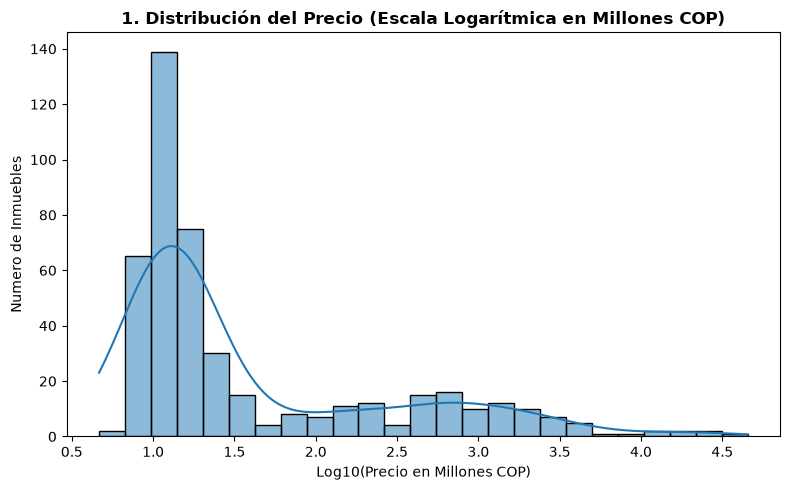

In [ ]:
plt.figure(figsize=(8, 5))

# Histrograma con curva de densidad
sns.histplot(np.log10(df['Precio_M']), kde=True, color='#1f77b4', bins=25)

plt.title(
    '1. Distribución del Precio (Escala Logarítmica en Millones COP)',
    fontsize=12,
    fontweight='bold',)

plt.xlabel('Log10(Precio en Millones COP)')
plt.ylabel('Numero de Inmuebles')

plt.tight_layout()
plt.show()

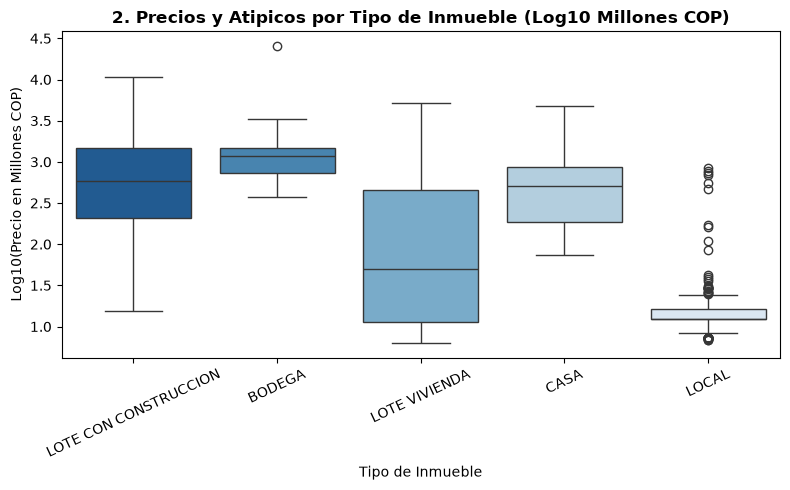

In [17]:
# Filtrar 5 tipos de inmuebles mas frecuentes
top_tipos = df['Tipo de Inmueble'].value_counts().head(5).index
df_top_tipos = df[df['Tipo de Inmueble'].isin(top_tipos)].copy()
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_top_tipos,
    x='Tipo de Inmueble',
    y=np.log10(df_top_tipos['Precio_M']),
    palette='Blues_r',
    hue='Tipo de Inmueble'
)
plt.title(
    '2. Precios y Atipicos por Tipo de Inmueble (Log10 Millones COP)',
    fontsize=12,
    fontweight='bold'
)
plt.xlabel('Tipo de Inmueble')
plt.ylabel('Log10(Precio en Millones COP)')
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

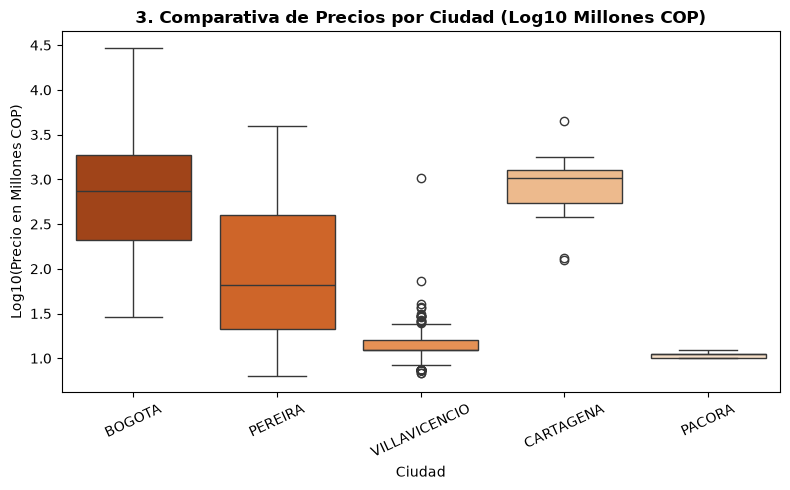

In [18]:
# Filtrar las 5 ciudades con mayor presencia
top_ciudades = df['Ciudad'].value_counts().head(5).index
df_top_ciudades = df[df['Ciudad'].isin(top_ciudades)].copy()

plt.figure(figsize=(8, 5))

# Diagrama de cajas por ciudad
sns.boxplot(
    data=df_top_ciudades,
    x='Ciudad',
    y=np.log10(df_top_ciudades['Precio_M']),
    palette='Oranges_r',
    hue='Ciudad'
)
plt.title(
    '3. Comparativa de Precios por Ciudad (Log10 Millones COP)',
    fontsize=12,
    fontweight='bold'
)
plt.xlabel('Ciudad')
plt.ylabel('Log10(Precio en Millones COP)')
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

Detalle Disponibilidad
COMERCIALIZABLE                     289
COMERCIALIZABLE CON RESTRICCION      83
COMERCIALIZABLE TERCEROS             41
EN PUJA                              23
COMERCIALIZABLE FIDUCIA              13
COMERCIALIZABLE VENTA ANTICIPADA      7
Name: count, dtype: int64


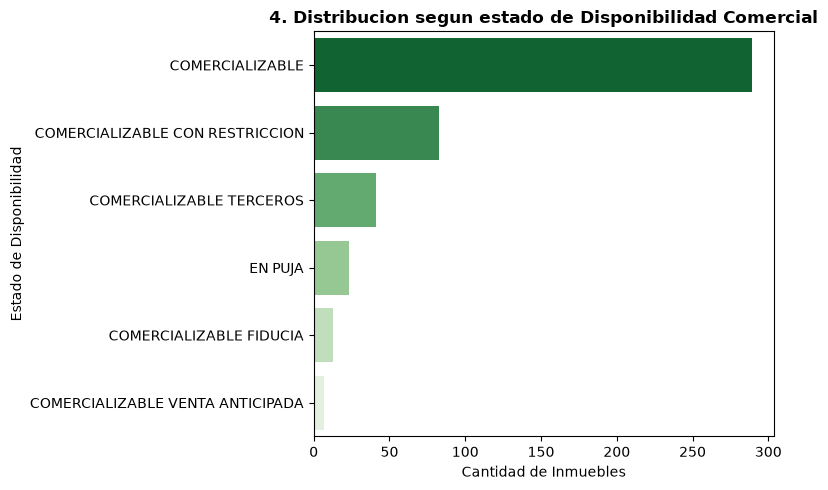

In [21]:
# Conteo por estado de disponibilidad
dispo_count = df['Detalle Disponibilidad'].value_counts()

print(dispo_count)
plt.figure(figsize=(8, 5))

# Grafico  de barras horizontales
sns.barplot(x=dispo_count.values, y=dispo_count.index, palette='Greens_r', hue=dispo_count.index)

plt.title(
    '4. Distribucion segun estado de Disponibilidad Comercial',
    fontsize=12,
    fontweight='bold'
)
plt.xlabel('Cantidad de Inmuebles')
plt.ylabel('Estado de Disponibilidad')

plt.tight_layout()
plt.show()